In [1]:
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

info_path = '../data/info_participants.xlsx'
os.makedirs('model_assets', exist_ok=True)
OUTPUT_PATH = 'model_assets/eda/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

PROCESSED = pathlib.Path("../data/processed/modeling_df.parquet")
REFERENCE = pathlib.Path("../data/reference/modeling_df.parquet")

if PROCESSED.exists():
    modeling_parquet = PROCESSED
else:
    print(
        "[warning] data/processed/modeling_df.parquet not found — "
        "falling back to committed frozen reference at data/reference/. "
        "Run bin/build.sh for the fresh pipeline output."
    )
    modeling_parquet = REFERENCE

[warning] data/processed/modeling_df.parquet not found — falling back to committed frozen reference at data/reference/. Run bin/build.sh for the fresh pipeline output.


# EDA

Read-only pass over `data/processed/modeling_df.parquet`. Outcome is `cadence_error` (spm).

- sanity-check parquet against DATA_DICTIONARY
- cadence_error by sex, speed, subject
- poke at the left tail / detector undercount
- QC flags and trial-count symmetry

Nothing is written from here. Interpretations go in `dev_docs/active/`.

## Load

In [2]:
df = pd.read_parquet(modeling_parquet)

# quick shape / eligibility check before doing anything else
print(f'shape: {df.shape}')
print(f'n subjects: {df["subject_id"].nunique()}')
print(f'n eligible: {df["modeling_include"].sum()}')
print(f'n excluded: {(~df["modeling_include"]).sum()}')
df.info()

shape: (2818, 35)
n subjects: 47
n eligible: 2781
n excluded: 37
<class 'pandas.DataFrame'>
RangeIndex: 2818 entries, 0 to 2817
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_id                 2818 non-null   str    
 1   sex                        2818 non-null   str    
 2   age                        2818 non-null   int64  
 3   height_cm                  2818 non-null   float64
 4   mass_kg                    2818 non-null   float64
 5   iad_mm                     2818 non-null   float64
 6   leg_length_mm              2818 non-null   float64
 7   speed                      2818 non-null   str    
 8   leading_leg                2818 non-null   str    
 9   trial_num                  2818 non-null   str    
 10  cadence_imu                2796 non-null   float64
 11  trial_duration_s           2799 non-null   float64
 12  cadence_imu_right_femur    2799 non-null   float64

## Cohort composition

- expected: 17F / 30M across 47 usable subjects
- parquet copies from xlsx at build time, so they should agree
- cross-check both sides

In [3]:
# parquet side: one row per subject
sex_parq = (
    df.groupby('subject_id')['sex']
      .first()
      .value_counts()
      .rename('n_parquet')
)

# spreadsheet side, filtered to the 47 usable subjects
info = pd.read_excel(info_path)
info['subject_id'] = info['ID'].apply(lambda x: f'{int(x):02d}')
usable = sorted(df['subject_id'].unique())
sex_xlsx = (
    info[info['subject_id'].isin(usable)]['Gender']
        .value_counts()
        .rename('n_xlsx')
)

pd.concat([sex_parq, sex_xlsx], axis=1)

,n_parquet,n_xlsx
M,30,30
F,17,17


## Primary outcome: cadence_error

- numeric summary before plotting
- split by sex and by speed

In [4]:
elig = df[df['modeling_include']].copy()
print(f'n eligible trials: {len(elig)}\n')

# overall
print('cadence_error (spm), all eligible:')
print(elig['cadence_error'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(2))

# by sex
print('\nby sex:')
print(elig.groupby('sex')['cadence_error'].describe(percentiles=[0.05, 0.5, 0.95]).round(2))

# by speed
print('\nby speed:')
print(elig.groupby('speed')['cadence_error'].describe(percentiles=[0.05, 0.5, 0.95]).round(2))

n eligible trials: 2781

cadence_error (spm), all eligible:
count    2781.00
mean       -5.52
std        11.22
min       -74.28
1%        -45.74
5%        -29.68
50%        -2.96
95%         6.12
99%        25.33
max        33.57
Name: cadence_error, dtype: float64

by sex:
      count  mean    std    min     5%   50%   95%    max
sex                                                      
F    1016.0 -6.39  11.74 -61.30 -32.41 -2.90  5.93  31.43
M    1765.0 -5.03  10.89 -74.28 -26.77 -2.99  6.17  33.57

by speed:
       count  mean    std    min     5%   50%    95%    max
speed                                                      
comf   933.0 -4.57   9.18 -74.28 -25.83 -2.64   4.33  25.13
fast   920.0 -6.33   9.30 -70.26 -24.40 -4.02   2.54  31.43
slow   928.0 -5.68  14.34 -64.46 -33.81 -2.28  10.02  33.57


### Distributions

- overall hist, box by sex, box by sex x speed
- fixed palette F=orange / M=blue, speed ordered slow->comf->fast, reused throughout

/var/folders/n9/8tgrbsbx61n9yzm2f0wrchh00000gp/T/ipykernel_76661/1234071899.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/n9/8tgrbsbx61n9yzm2f0wrchh00000gp/T/ipykernel_76661/1234071899.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, positions=positions, labels=labels,


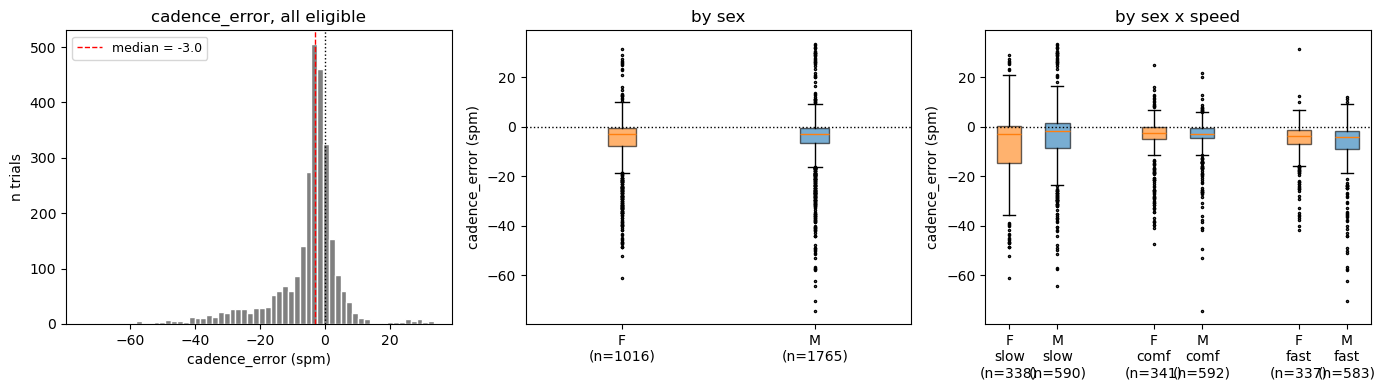

In [5]:
# palette + ordering reused for every plot below
SEX_COLORS = {'F': 'tab:orange', 'M': 'tab:blue'}
SEX_ORDER = ['F', 'M']
SPEED_ORDER = ['slow', 'comf', 'fast']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# overall histogram
ax = axes[0]
ax.hist(elig['cadence_error'], bins=60, color='gray', edgecolor='white')
med = elig['cadence_error'].median()
ax.axvline(0, color='black', linestyle=':', linewidth=1)
ax.axvline(med, color='red', linestyle='--', linewidth=1, label=f'median = {med:.1f}')
ax.set_xlabel('cadence_error (spm)')
ax.set_ylabel('n trials')
ax.set_title('cadence_error, all eligible')
ax.legend(fontsize=9)

# box by sex
ax = axes[1]
data_by_sex = [elig.loc[elig['sex'] == s, 'cadence_error'].values for s in SEX_ORDER]
bp = ax.boxplot(
    data_by_sex,
    labels=[f'{s}\n(n={len(d)})' for s, d in zip(SEX_ORDER, data_by_sex)],
    patch_artist=True, showfliers=True,
    flierprops=dict(marker='.', markersize=3),
)
for patch, s in zip(bp['boxes'], SEX_ORDER):
    patch.set_facecolor(SEX_COLORS[s])
    patch.set_alpha(0.6)
ax.axhline(0, color='black', linestyle=':', linewidth=1)
ax.set_ylabel('cadence_error (spm)')
ax.set_title('by sex')

# box by sex x speed
ax = axes[2]
positions, labels, box_data, box_colors = [], [], [], []
for i, speed in enumerate(SPEED_ORDER):
    for j, sex in enumerate(SEX_ORDER):
        subset = elig[(elig['speed'] == speed) & (elig['sex'] == sex)]['cadence_error'].values
        box_data.append(subset)
        positions.append(i * 3 + j)
        labels.append(f'{sex}\n{speed}\n(n={len(subset)})')
        box_colors.append(SEX_COLORS[sex])

bp = ax.boxplot(box_data, positions=positions, labels=labels,
                patch_artist=True, showfliers=True,
                flierprops=dict(marker='.', markersize=3))
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.axhline(0, color='black', linestyle=':', linewidth=1)
ax.set_ylabel('cadence_error (spm)')
ax.set_title('by sex x speed')

plt.tight_layout()
fig.savefig(f"{OUTPUT_PATH}eda_outcome_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## Left tail

- min -74, q01 -46, right tail maxes at +34
- do the worst trials cluster by subject, sex, or speed?

In [6]:
threshold = -30  # roughly the 5th pctile; used a few times below

# worst 20 trials: who owns them, what sex/speed, and did qc_flags catch them?
worst = elig.nsmallest(20, 'cadence_error')[
    ['subject_id', 'sex', 'speed', 'leading_leg', 'trial_num',
     'cadence_imu', 'cadence_plate', 'cadence_error',
     'n_strikes_plate', 'qc_flags']
].reset_index(drop=True)
print('worst 20 trials by cadence_error:')
print(worst.to_string())

left_tail = elig[elig['cadence_error'] < threshold]
print(f'\nleft-tail trials (cadence_error < {threshold}): {len(left_tail)} ({len(left_tail) / len(elig):.1%})')
print(f'subjects owning them: {left_tail["subject_id"].nunique()} / 47')

print('\ntop 10 subjects by left-tail count:')
print(left_tail['subject_id'].value_counts().head(10).to_string())

print('\nby (sex, speed):')
print(left_tail.groupby(['sex', 'speed']).size().to_string())

worst 20 trials by cadence_error:
   subject_id sex speed leading_leg trial_num  cadence_imu  cadence_plate  cadence_error  n_strikes_plate qc_flags
0          04   M  comf           r        01    40.665625     114.942529     -74.276904              3.0         
1          22   M  fast           l        09    75.905213     146.163216     -70.258002              3.0         
2          09   M  slow           l        07    31.925581      96.385542     -64.459961              3.0         
3          22   M  fast           r        07    77.000000     139.211137     -62.211137              3.0         
4          39   F  slow           r        10   112.612500     173.913043     -61.300543              4.0         
5          28   M  fast           r        01    62.972477     120.967742     -57.995265              3.0         
6          50   M  fast           l        06    73.643052     131.147541     -57.504489              3.0         
7          09   M  slow           l        06 

### Rate-adjusted

- raw counts aren't comparable, denominators differ
- rate by (sex, speed)

In [7]:
rates = (
    elig.assign(left_tail=elig['cadence_error'] < threshold)
        .groupby(['sex', 'speed'])['left_tail']
        .agg(['sum', 'count'])
        .rename(columns={'sum': 'n_left_tail', 'count': 'n_eligible'})
)
rates['rate'] = rates['n_left_tail'] / rates['n_eligible']
print('by (sex, speed):')
print(rates.round(3).to_string())

# marginals
by_sex = (
    elig.assign(lt=elig['cadence_error'] < threshold)
        .groupby('sex')['lt'].agg(['sum', 'count'])
)
by_sex['rate'] = by_sex['sum'] / by_sex['count']
print('\nmarginal by sex:')
print(by_sex.round(3).to_string())

by_speed = (
    elig.assign(lt=elig['cadence_error'] < threshold)
        .groupby('speed')['lt'].agg(['sum', 'count'])
)
by_speed['rate'] = by_speed['sum'] / by_speed['count']
print('\nmarginal by speed:')
print(by_speed.round(3).to_string())

by (sex, speed):
           n_left_tail  n_eligible   rate
sex speed                                
F   comf            19         341  0.056
    fast             8         337  0.024
    slow            42         338  0.124
M   comf            11         592  0.019
    fast            24         583  0.041
    slow            29         590  0.049

marginal by sex:
     sum  count   rate
sex                   
F     69   1016  0.068
M     64   1765  0.036

marginal by speed:
       sum  count   rate
speed                   
comf    30    933  0.032
fast    32    920  0.035
slow    71    928  0.077


### Heatmap

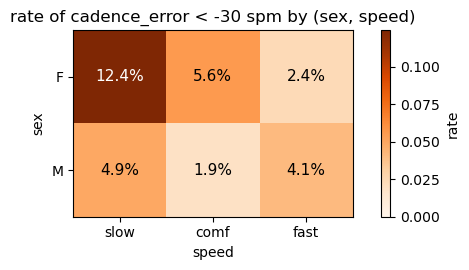

In [8]:
rate_matrix = (
    rates['rate']
        .unstack('speed')
        .reindex(index=['F', 'M'], columns=SPEED_ORDER)
)

fig, ax = plt.subplots(figsize=(6, 2.8))
im = ax.imshow(rate_matrix.values, cmap='Oranges',
               vmin=0, vmax=rate_matrix.values.max())

# annotate each cell with its rate
for i in range(rate_matrix.shape[0]):
    for j in range(rate_matrix.shape[1]):
        r = rate_matrix.values[i, j]
        ax.text(j, i, f'{r:.1%}', ha='center', va='center',
                color='black' if r < 0.08 else 'white', fontsize=11)

ax.set_xticks(range(rate_matrix.shape[1]), rate_matrix.columns)
ax.set_yticks(range(rate_matrix.shape[0]), rate_matrix.index)
ax.set_xlabel('speed')
ax.set_ylabel('sex')
ax.set_title('rate of cadence_error < -30 spm by (sex, speed)')
fig.colorbar(im, ax=ax, label='rate')
plt.tight_layout()
plt.show()

## Anthropometrics by sex

- Model 4 decomposes any sex effect into leg length / IAD / mass
- decomposition only has power if those predictors vary by sex in this cohort

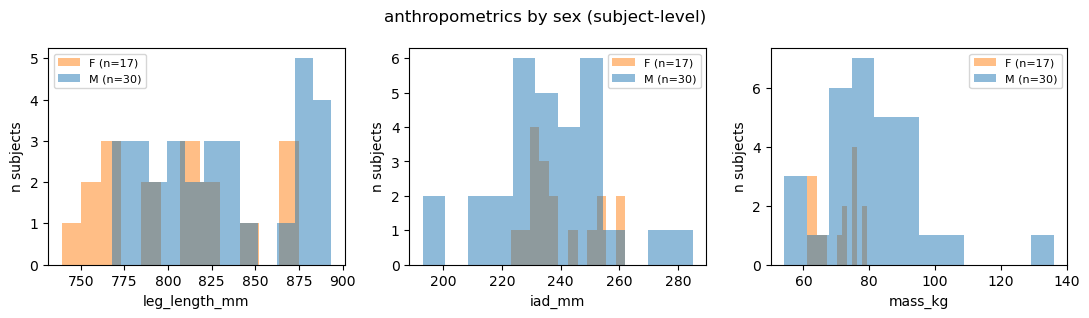

In [9]:
# collapse to one row per subject: anthros are subject-level, not trial-level
subjects_df = df.groupby('subject_id').first().reset_index()
anthros = ['leg_length_mm', 'iad_mm', 'mass_kg']

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, col in zip(axes, anthros):
    for sex in SEX_ORDER:
        vals = subjects_df.loc[subjects_df['sex'] == sex, col]
        ax.hist(vals, bins=12, alpha=0.5, color=SEX_COLORS[sex],
                label=f'{sex} (n={len(vals)})')
    ax.set_xlabel(col)
    ax.set_ylabel('n subjects')
    ax.legend(fontsize=8)
fig.suptitle('anthropometrics by sex (subject-level)')
plt.tight_layout()
fig.savefig(f"{OUTPUT_PATH}anthropometrics_by_sex.png", dpi=200, bbox_inches="tight")
plt.show()

## Demographics grid

- age, height, mass, IAD, leg length, trial count per subject
- is sex confounded with any structural variable in this cohort?

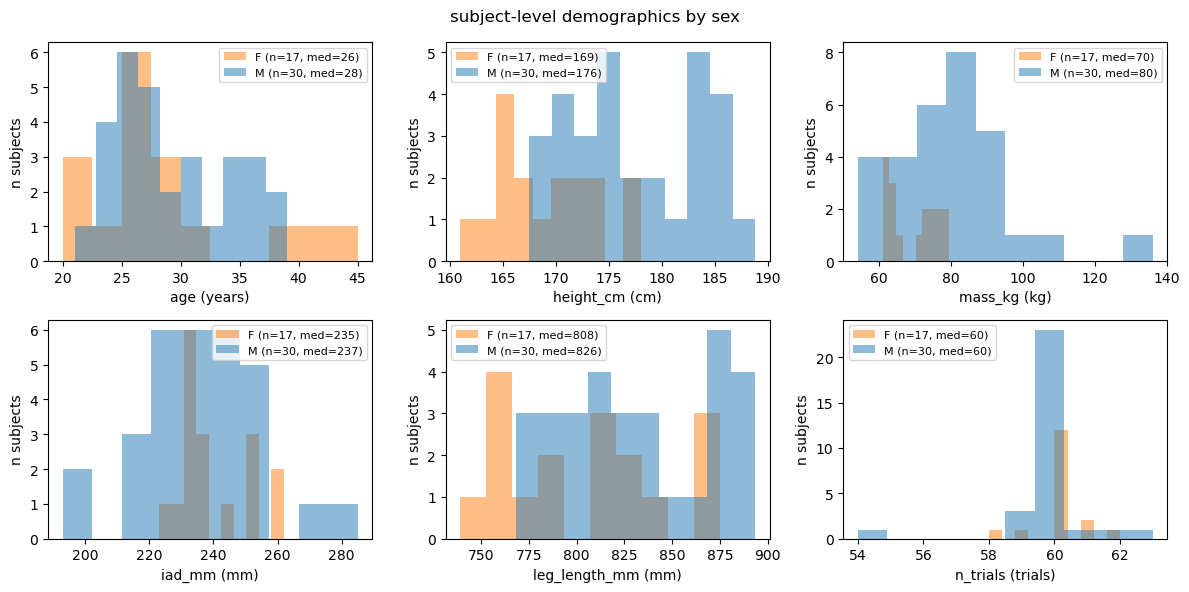

In [10]:
# one row per subject with all demographics + trial count
subj = (
    df.groupby('subject_id')
      .agg(sex=('sex', 'first'),
           age=('age', 'first'),
           height_cm=('height_cm', 'first'),
           mass_kg=('mass_kg', 'first'),
           iad_mm=('iad_mm', 'first'),
           leg_length_mm=('leg_length_mm', 'first'),
           n_trials=('trial_num', 'count'))
      .reset_index()
)

panels = [
    ('age', 'years'),
    ('height_cm', 'cm'),
    ('mass_kg', 'kg'),
    ('iad_mm', 'mm'),
    ('leg_length_mm', 'mm'),
    ('n_trials', 'trials'),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (col, unit) in zip(axes.flat, panels):
    for sex in SEX_ORDER:
        vals = subj.loc[subj['sex'] == sex, col]
        ax.hist(vals, bins=10, alpha=0.5, color=SEX_COLORS[sex],
                label=f'{sex} (n={len(vals)}, med={vals.median():.0f})')
    ax.set_xlabel(f'{col} ({unit})')
    ax.set_ylabel('n subjects')
    ax.legend(fontsize=8)
fig.suptitle('subject-level demographics by sex')
plt.tight_layout()
plt.show()

### Anthropometric pairwise

- Model 4 uses leg length, IAD, mass
- add height for reference (literature proxy for leg length)
- how collinear are the four?

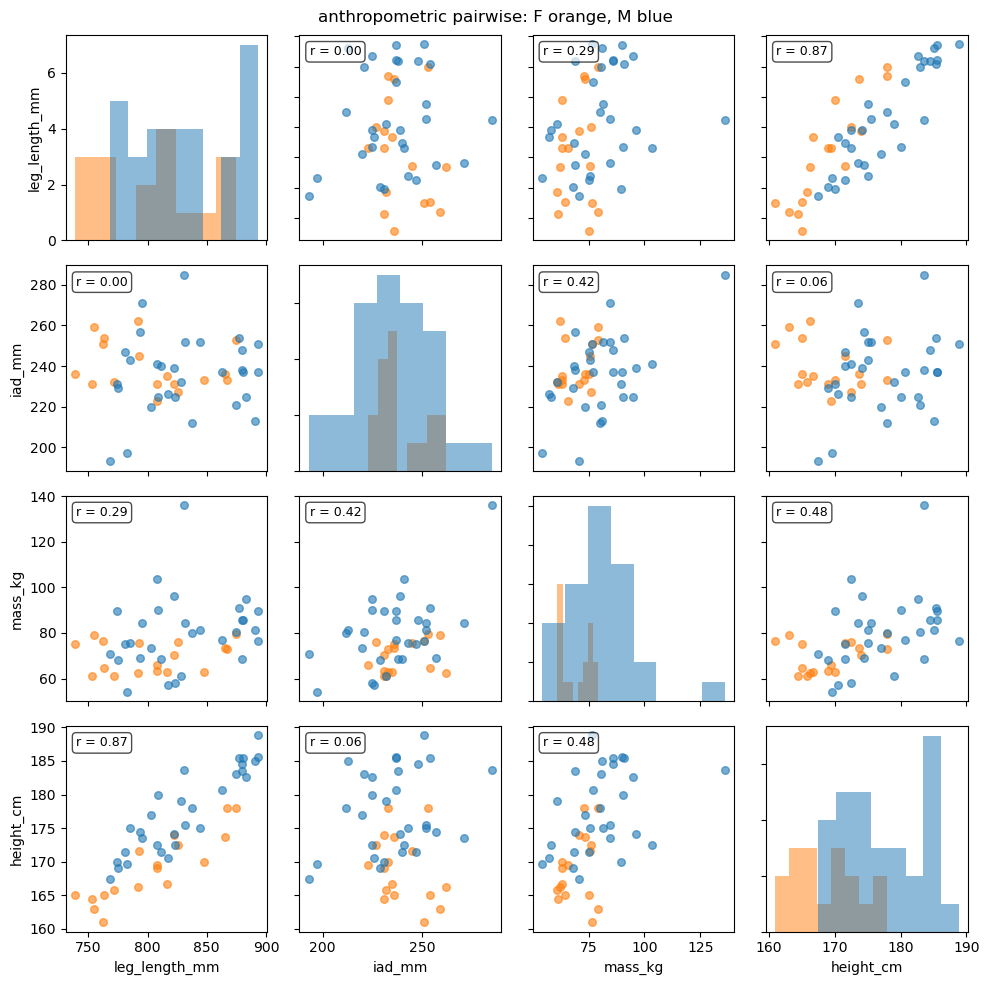


Pearson correlations (subject-level):
               leg_length_mm  iad_mm  mass_kg  height_cm
leg_length_mm           1.00    0.00     0.29       0.87
iad_mm                  0.00    1.00     0.42       0.06
mass_kg                 0.29    0.42     1.00       0.48
height_cm               0.87    0.06     0.48       1.00


In [11]:
anthros = ['leg_length_mm', 'iad_mm', 'mass_kg', 'height_cm']
n = len(anthros)

fig, axes = plt.subplots(n, n, figsize=(10, 10))
for i, row_col in enumerate(anthros):
    for j, col_col in enumerate(anthros):
        ax = axes[i, j]
        if i == j:
            # diagonal: histogram by sex
            for sex in SEX_ORDER:
                vals = subj.loc[subj['sex'] == sex, row_col]
                ax.hist(vals, bins=8, alpha=0.5, color=SEX_COLORS[sex])
            ax.set_ylabel('')
        else:
            # off-diagonal: scatter + Pearson r
            for sex in SEX_ORDER:
                sub = subj[subj['sex'] == sex]
                ax.scatter(sub[col_col], sub[row_col],
                           c=SEX_COLORS[sex], alpha=0.6, s=30, label=sex)
            r = subj[[col_col, row_col]].corr().iloc[0, 1]
            ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes,
                    fontsize=9, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

        if i == n - 1:
            ax.set_xlabel(col_col)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(row_col)
        else:
            ax.set_yticklabels([])

fig.suptitle('anthropometric pairwise: F orange, M blue')
plt.tight_layout()
plt.show()

print('\nPearson correlations (subject-level):')
print(subj[anthros].corr().round(2).to_string())

## Per-subject mean error (Model 2 motivation)

- each dot = one subject's mean cadence_error across ~60 trials, sorted
- if subject means cluster around cohort mean, Model 1 (full pooling) is enough
- if they spread, Model 2 earns its keep

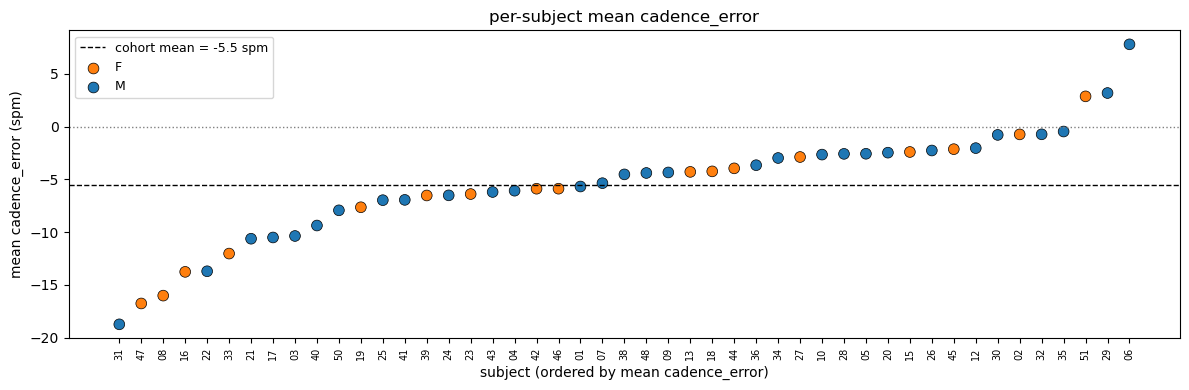

subject mean cadence_error
  range: -18.7 to 7.8 spm
  between-subject sd: 5.15 spm
  trial-level sd (cohort): 11.22 spm


In [12]:
subj_means = (
    elig.groupby('subject_id')
        .agg(mean_error=('cadence_error', 'mean'),
             n=('cadence_error', 'count'),
             sex=('sex', 'first'))
        .sort_values('mean_error')
        .reset_index()
)

cohort_mean = elig['cadence_error'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
colors = [SEX_COLORS[s] for s in subj_means['sex']]
ax.scatter(range(len(subj_means)), subj_means['mean_error'],
           c=colors, s=60, edgecolor='black', linewidth=0.5)

ax.axhline(cohort_mean, color='black', linestyle='--', linewidth=1,
           label=f'cohort mean = {cohort_mean:.1f} spm')
ax.axhline(0, color='gray', linestyle=':', linewidth=1)

# scatter colors aren't auto-legended, inject proxy handles
for sex in SEX_ORDER:
    ax.scatter([], [], c=SEX_COLORS[sex], s=60, edgecolor='black',
               linewidth=0.5, label=sex)

ax.set_xticks(range(len(subj_means)))
ax.set_xticklabels(subj_means['subject_id'], rotation=90, fontsize=7)
ax.set_xlabel('subject (ordered by mean cadence_error)')
ax.set_ylabel('mean cadence_error (spm)')
ax.set_title('per-subject mean cadence_error')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# quick sanity on spread: compare between-subject vs trial-level variation
print(f'subject mean cadence_error')
print(f'  range: {subj_means["mean_error"].min():.1f} to {subj_means["mean_error"].max():.1f} spm')
print(f'  between-subject sd: {subj_means["mean_error"].std():.2f} spm')
print(f'  trial-level sd (cohort): {elig["cadence_error"].std():.2f} spm')

### Per-subject distributions

- same subject ordering as above
- do widths stay constant (mean-shift story) or widen (variance story)?
- feeds the Model 2 spec: subject-level sigma or not

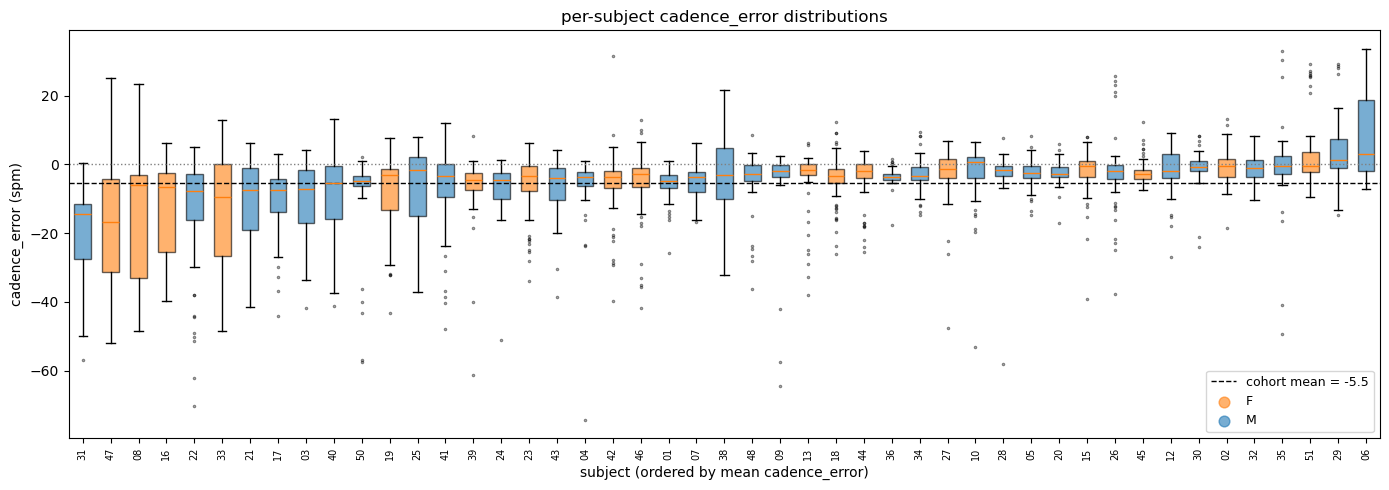

per-subject sd of cadence_error
  median: 9.59 spm
  range: 2.53 to 17.80 spm

top 5 noisiest:
subject_id  std_cadence_error sex
        08          17.801356   F
        22          17.291081   M
        47          16.043612   F
        33          15.410184   F
        16          13.106133   F


In [13]:
ordered_subjects = subj_means['subject_id'].tolist()
subject_sex = dict(zip(subj_means['subject_id'], subj_means['sex']))

data = [elig.loc[elig['subject_id'] == sid, 'cadence_error'].values
        for sid in ordered_subjects]

fig, ax = plt.subplots(figsize=(14, 5))
bp = ax.boxplot(data, positions=range(len(ordered_subjects)),
                patch_artist=True, showfliers=True,
                flierprops=dict(marker='.', markersize=3, alpha=0.5),
                widths=0.6)

for patch, sid in zip(bp['boxes'], ordered_subjects):
    patch.set_facecolor(SEX_COLORS[subject_sex[sid]])
    patch.set_alpha(0.6)

ax.axhline(0, color='gray', linestyle=':', linewidth=1)
ax.axhline(elig['cadence_error'].mean(), color='black', linestyle='--',
           linewidth=1, label=f'cohort mean = {elig["cadence_error"].mean():.1f}')

ax.set_xticks(range(len(ordered_subjects)))
ax.set_xticklabels(ordered_subjects, rotation=90, fontsize=7)
ax.set_xlabel('subject (ordered by mean cadence_error)')
ax.set_ylabel('cadence_error (spm)')
ax.set_title('per-subject cadence_error distributions')

for sex in SEX_ORDER:
    ax.scatter([], [], c=SEX_COLORS[sex], s=60, alpha=0.6, label=sex)
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

# noisiest subjects: are the big widths driven by left-tail outliers?
subj_std = (
    elig.groupby('subject_id')['cadence_error']
        .std()
        .rename('std_cadence_error')
        .reset_index()
        .merge(subj_means[['subject_id', 'sex']], on='subject_id')
)
print(f'per-subject sd of cadence_error')
print(f'  median: {subj_std["std_cadence_error"].median():.2f} spm')
print(f'  range: {subj_std["std_cadence_error"].min():.2f} to {subj_std["std_cadence_error"].max():.2f} spm')
print(f'\ntop 5 noisiest:')
print(subj_std.nlargest(5, 'std_cadence_error').to_string(index=False))

## Error vs underlying cadence

- pure additive bias -> flat line offset from zero
- multiplicative bias -> nonzero slope
- three panels by speed

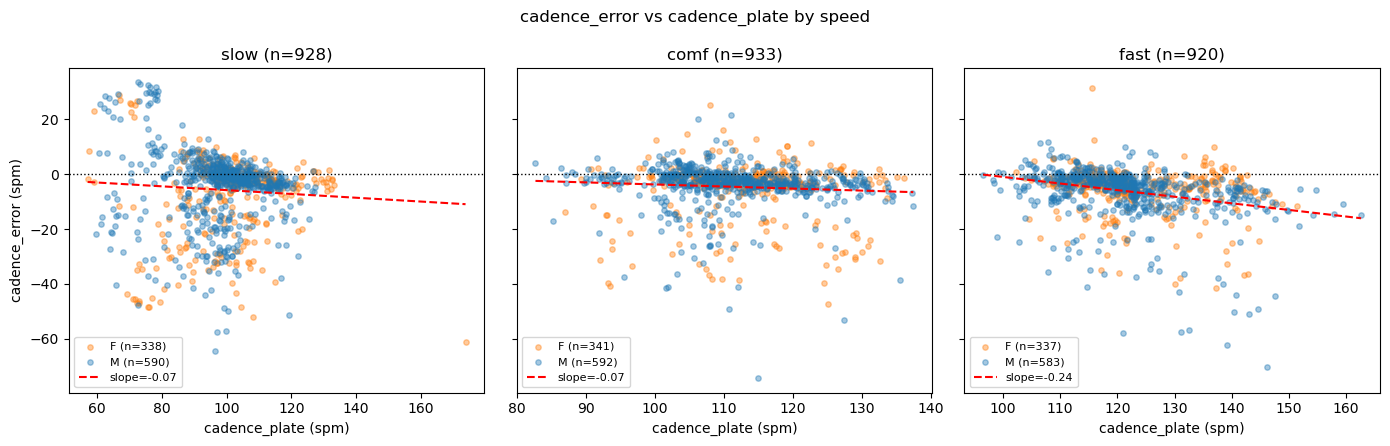

slope of cadence_error ~ cadence_plate, by (sex, speed):
  F slow: slope = +0.082, intercept = -16.1, n = 338
  M slow: slope = -0.156, intercept = +10.7, n = 590
  F comf: slope = -0.046, intercept = -0.4, n = 341
  M comf: slope = -0.079, intercept = +4.8, n = 592
  F fast: slope = -0.137, intercept = +11.3, n = 337
  M fast: slope = -0.307, intercept = +30.6, n = 583


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for ax, speed in zip(axes, SPEED_ORDER):
    sub = elig[elig['speed'] == speed]
    for sex in SEX_ORDER:
        ss = sub[sub['sex'] == sex]
        ax.scatter(ss['cadence_plate'], ss['cadence_error'],
                   c=SEX_COLORS[sex], alpha=0.4, s=15,
                   label=f'{sex} (n={len(ss)})')

    ax.axhline(0, color='black', linestyle=':', linewidth=1)
    # OLS slope on the combined sex data: quick read on additive vs multiplicative
    x = sub['cadence_plate'].values
    y = sub['cadence_error'].values
    slope, intercept = np.polyfit(x, y, 1)
    xl = np.linspace(x.min(), x.max(), 50)
    ax.plot(xl, slope * xl + intercept, color='red', linestyle='--',
            linewidth=1.5, label=f'slope={slope:.2f}')

    ax.set_xlabel('cadence_plate (spm)')
    ax.set_title(f'{speed} (n={len(sub)})')
    ax.legend(fontsize=8, loc='lower left')

axes[0].set_ylabel('cadence_error (spm)')
fig.suptitle('cadence_error vs cadence_plate by speed')
plt.tight_layout()
fig.savefig(f"{OUTPUT_PATH}error_vs_cadence_by_speed.png", dpi=200, bbox_inches="tight")
plt.show()

# per (sex, speed) slopes: do the sexes track differently within a speed?
print('slope of cadence_error ~ cadence_plate, by (sex, speed):')
for speed in SPEED_ORDER:
    for sex in SEX_ORDER:
        sub = elig[(elig['speed'] == speed) & (elig['sex'] == sex)]
        if len(sub) > 10:
            s, i = np.polyfit(sub['cadence_plate'], sub['cadence_error'], 1)
            print(f'  {sex} {speed:4s}: slope = {s:+.3f}, intercept = {i:+.1f}, n = {len(sub)}')

## Subject mean error vs anthropometrics

- Model 4 predictors against the outcome at subject level
- which coefficients will actually move?

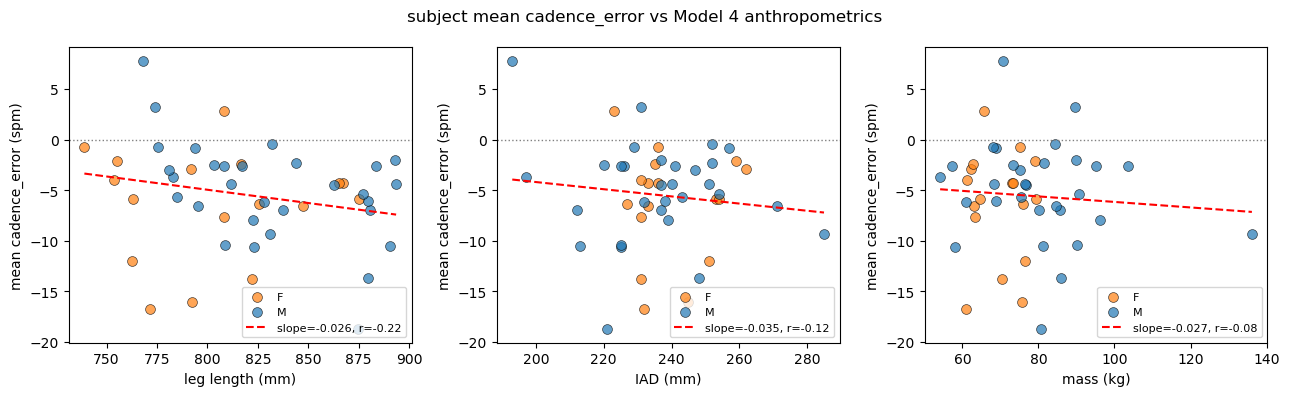

subject-level Pearson r with mean cadence_error:
  leg_length_mm: r = -0.221
  iad_mm: r = -0.118
  mass_kg: r = -0.076


In [15]:
# join subject-mean outcome to subject-level anthros
subj_full = subj_means.merge(
    subj[['subject_id', 'leg_length_mm', 'iad_mm', 'mass_kg']],
    on='subject_id',
)

anthros_m4 = [
    ('leg_length_mm', 'leg length (mm)'),
    ('iad_mm', 'IAD (mm)'),
    ('mass_kg', 'mass (kg)'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (col, label) in zip(axes, anthros_m4):
    for sex in SEX_ORDER:
        sub = subj_full[subj_full['sex'] == sex]
        ax.scatter(sub[col], sub['mean_error'],
                   c=SEX_COLORS[sex], alpha=0.7, s=50,
                   edgecolor='black', linewidth=0.5, label=sex)

    x = subj_full[col].values
    y = subj_full['mean_error'].values
    slope, intercept = np.polyfit(x, y, 1)
    r = np.corrcoef(x, y)[0, 1]
    xl = np.linspace(x.min(), x.max(), 50)
    ax.plot(xl, slope * xl + intercept, color='red', linestyle='--',
            linewidth=1.5, label=f'slope={slope:+.3f}, r={r:+.2f}')

    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel(label)
    ax.set_ylabel('mean cadence_error (spm)')
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('subject mean cadence_error vs Model 4 anthropometrics')
plt.tight_layout()
plt.show()

print('subject-level Pearson r with mean cadence_error:')
for col, _ in anthros_m4:
    r = subj_full[[col, 'mean_error']].corr().iloc[0, 1]
    print(f'  {col}: r = {r:+.3f}')

## Empirical CDF

- quantify tail asymmetry; mark q01/q05/q50/q95/q99
- preview for Model 1 PPC band: Normal should reproduce these, Student-t better on extremes

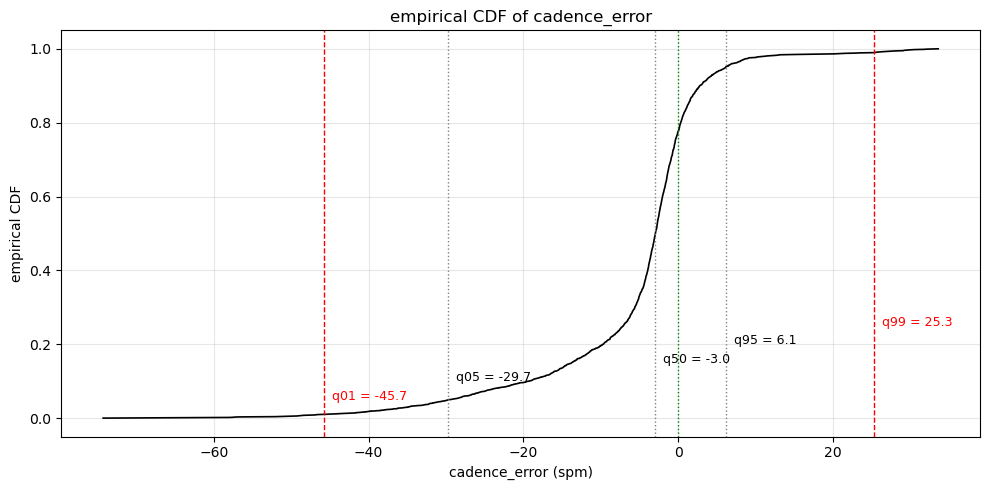

median: -2.96 spm
right (q99 - median): +28.30
left (median - q01): +42.78
right (q95 - median): +9.08
left (median - q05): +26.72

asymmetry ratio (left / right):
  1/99: 1.51
  5/95: 2.94


In [16]:
values = np.sort(elig['cadence_error'].values)
cdf = np.arange(1, len(values) + 1) / len(values)

q_levels = [0.01, 0.05, 0.5, 0.95, 0.99]
quantiles = elig['cadence_error'].quantile(q_levels)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(values, cdf, color='black', linewidth=1.2)

# annotate quantile lines, red for extremes
for idx, q in enumerate(q_levels):
    v = quantiles[q]
    is_extreme = q in (0.01, 0.99)
    ax.axvline(v, color='red' if is_extreme else 'gray',
               linestyle='--' if is_extreme else ':', linewidth=1)
    ax.text(v, 0.05 + idx * 0.05,
            f'  q{int(q*100):02d} = {v:.1f}',
            color='red' if is_extreme else 'black', fontsize=9)

ax.axvline(0, color='green', linestyle=':', linewidth=1)
ax.set_xlabel('cadence_error (spm)')
ax.set_ylabel('empirical CDF')
ax.set_title('empirical CDF of cadence_error')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# asymmetry ratio: left tail / right tail at 1/99 and 5/95
med = quantiles[0.5]
print(f'median: {med:.2f} spm')
print(f'right (q99 - median): {quantiles[0.99] - med:+.2f}')
print(f'left (median - q01): {med - quantiles[0.01]:+.2f}')
print(f'right (q95 - median): {quantiles[0.95] - med:+.2f}')
print(f'left (median - q05): {med - quantiles[0.05]:+.2f}')
print(f'\nasymmetry ratio (left / right):')
print(f'  1/99: {(med - quantiles[0.01]) / (quantiles[0.99] - med):.2f}')
print(f'  5/95: {(med - quantiles[0.05]) / (quantiles[0.95] - med):.2f}')

## QC flags

- `qc_flags` is pipe-delimited audit reasons per trial
- most trials are `(none)`
- flagged trials are the ones `build_modeling_df.py` decided needed downstream scrutiny

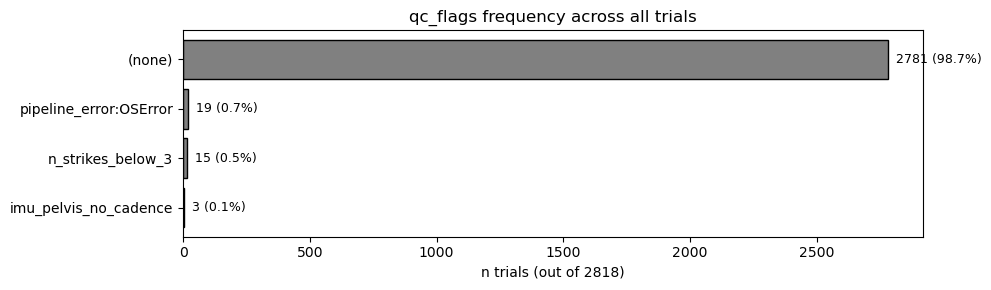

                           n        pct
imu_pelvis_no_cadence      3   0.106458
n_strikes_below_3         15   0.532292
pipeline_error:OSError    19   0.674237
(none)                  2781  98.687012


In [17]:
# split pipe-delimited flags into individual counts; treat '' as (none)
flag_counts = {}
for s in df['qc_flags']:
    if s == '' or pd.isna(s):
        flag_counts['(none)'] = flag_counts.get('(none)', 0) + 1
    else:
        for flag in s.split('|'):
            flag_counts[flag] = flag_counts.get(flag, 0) + 1

flag_df = (
    pd.Series(flag_counts, name='n')
      .sort_values(ascending=True)
      .to_frame()
)
flag_df['pct'] = flag_df['n'] / len(df) * 100

fig, ax = plt.subplots(figsize=(10, max(3, 0.4 * len(flag_df))))
ax.barh(flag_df.index, flag_df['n'], color='gray', edgecolor='black')
for i, (n, pct) in enumerate(zip(flag_df['n'], flag_df['pct'])):
    ax.text(n, i, f'  {n} ({pct:.1f}%)', va='center', fontsize=9)
ax.set_xlabel(f'n trials (out of {len(df)})')
ax.set_title('qc_flags frequency across all trials')
plt.tight_layout()
plt.show()

print(flag_df.to_string())

- any left-tail trials flagged?
- which subjects own the `imu_pelvis_no_cadence` trials?

In [18]:
left_tail_trials = elig[elig['cadence_error'] < -30]
print(f'left-tail trials with non-empty qc_flags: '
      f'{(left_tail_trials["qc_flags"] != "").sum()} / {len(left_tail_trials)}')

no_cad = df[df['qc_flags'].str.contains('imu_pelvis_no_cadence', na=False)]
print(f'\nimu_pelvis_no_cadence trials ({len(no_cad)}):')
print(no_cad[['subject_id', 'sex', 'speed', 'leading_leg', 'trial_num']].to_string(index=False))

left-tail trials with non-empty qc_flags: 0 / 133

imu_pelvis_no_cadence trials (3):
subject_id sex speed leading_leg trial_num
        41   M  slow           l        05
        41   M  slow           r        08
        41   M  slow           r        10


## Implausible cadence range

- ROADMAP flag: cadence outside [50, 200] spm is non-physiological
- adult walking is 90-130 spm; 50 is a shuffle, 200 is jogging

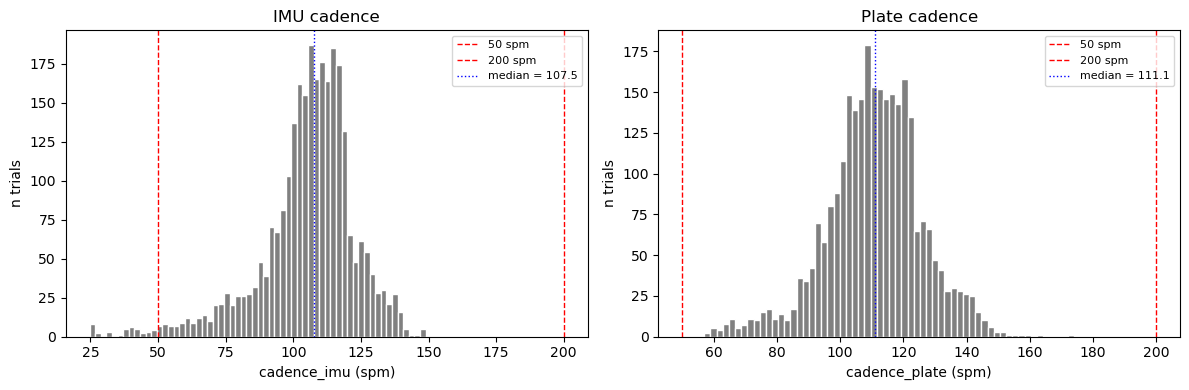

cadence_imu: 39 < 50 spm, 0 > 200 spm (of 2781 non-NaN)
cadence_plate: 0 < 50 spm, 0 > 200 spm (of 2781 non-NaN)


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in [
    (axes[0], 'cadence_imu', 'IMU cadence'),
    (axes[1], 'cadence_plate', 'Plate cadence'),
]:
    vals = elig[col].dropna()
    ax.hist(vals, bins=60, color='gray', edgecolor='white')
    ax.axvline(50, color='red', linestyle='--', linewidth=1, label='50 spm')
    ax.axvline(200, color='red', linestyle='--', linewidth=1, label='200 spm')
    ax.axvline(vals.median(), color='blue', linestyle=':', linewidth=1,
               label=f'median = {vals.median():.1f}')
    ax.set_xlabel(f'{col} (spm)')
    ax.set_ylabel('n trials')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

for col in ['cadence_imu', 'cadence_plate']:
    vals = elig[col].dropna()
    n_low = (vals < 50).sum()
    n_high = (vals > 200).sum()
    print(f'{col}: {n_low} < 50 spm, {n_high} > 200 spm (of {len(vals)} non-NaN)')

- zoom in on the sub-50 cases

In [20]:
# sub-50 cadence is physiologically implausible; mostly detector-undercount
implausible_imu = elig[elig['cadence_imu'] < 50]
print(f'implausible IMU trials: {len(implausible_imu)}')
print(f'  also in left-tail set (< -30 spm): '
      f'{(implausible_imu["cadence_error"] < -30).sum()}')
print(f'  worst cadence_error: {implausible_imu["cadence_error"].min():.1f} spm')
print(f'  by sex: {implausible_imu["sex"].value_counts().to_dict()}')
print(f'  by speed: {implausible_imu["speed"].value_counts().to_dict()}')

implausible IMU trials: 39
  also in left-tail set (< -30 spm): 30
  worst cadence_error: -74.3 spm
  by sex: {'M': 23, 'F': 16}
  by speed: {'slow': 38, 'comf': 1}


## Exclusions

- 37 total (1.3% of all trials)
- cohort-wide or subject-concentrated?

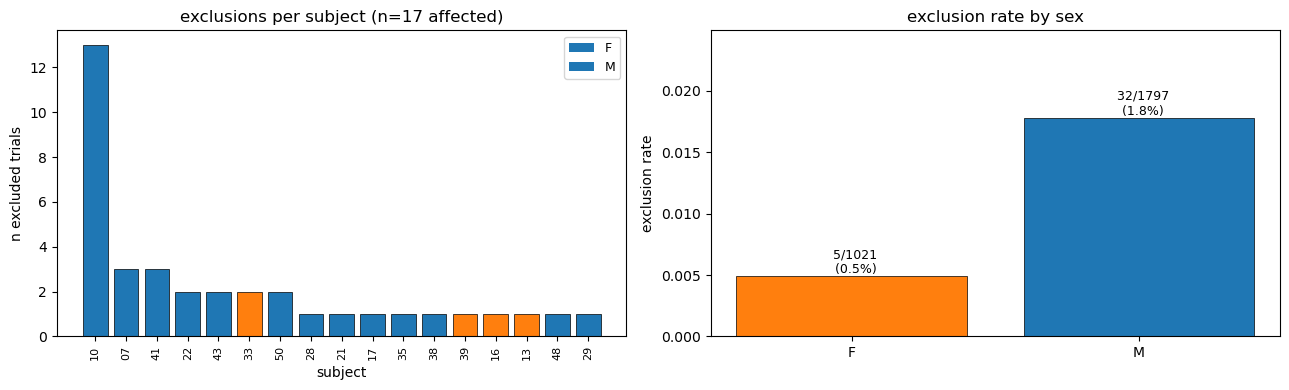

total exclusions: 37 / 2818 (1.3%)
subjects affected: 17 / 47

top 5 by exclusion count:
subject_id  n_excluded sex
        10          13   M
        07           3   M
        41           3   M
        22           2   M
        43           2   M


In [21]:
excluded = df[~df['modeling_include']]

# per-subject exclusion counts, sorted so the worst offenders are visible
excl_by_subject = (
    excluded.groupby('subject_id')
            .agg(n_excluded=('modeling_include', 'size'),
                 sex=('sex', 'first'))
            .reset_index()
            .sort_values('n_excluded', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
colors = [SEX_COLORS[s] for s in excl_by_subject['sex']]
ax.bar(range(len(excl_by_subject)), excl_by_subject['n_excluded'],
       color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(excl_by_subject)))
ax.set_xticklabels(excl_by_subject['subject_id'], rotation=90, fontsize=8)
ax.set_xlabel('subject')
ax.set_ylabel('n excluded trials')
ax.set_title(f'exclusions per subject (n={len(excl_by_subject)} affected)')
for sex in SEX_ORDER:
    ax.bar([], [], color=SEX_COLORS[sex], label=sex)
ax.legend(fontsize=9)

# exclusion rate by sex: any sex imbalance in exclusions?
ax = axes[1]
by_sex = (
    df.groupby('sex')
      .agg(n_excluded=('modeling_include', lambda x: (~x).sum()),
           n_total=('modeling_include', 'size'))
      .reset_index()
)
by_sex['rate'] = by_sex['n_excluded'] / by_sex['n_total']

x = range(len(by_sex))
ax.bar(x, by_sex['rate'], color=[SEX_COLORS[s] for s in by_sex['sex']],
       edgecolor='black', linewidth=0.5)
for i, row in by_sex.iterrows():
    ax.text(i, row['rate'],
            f'  {row["n_excluded"]}/{row["n_total"]}\n  ({row["rate"]:.1%})',
            ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(by_sex['sex'])
ax.set_ylabel('exclusion rate')
ax.set_title('exclusion rate by sex')
ax.set_ylim(0, by_sex['rate'].max() * 1.4)

plt.tight_layout()
fig.savefig(f"{OUTPUT_PATH}exclusion_rate_by_sex.png", dpi=200, bbox_inches="tight")
plt.show()

print(f'total exclusions: {len(excluded)} / {len(df)} ({len(excluded)/len(df):.1%})')
print(f'subjects affected: {excl_by_subject["subject_id"].nunique()} / 47')
print(f'\ntop 5 by exclusion count:')
print(excl_by_subject.head(5).to_string(index=False))

- subject 10 has the bulk; which flag?

In [22]:
subj_10_excl = df[(df['subject_id'] == '10') & (~df['modeling_include'])]
print('subject 10 exclusions by qc_flags:')
print(subj_10_excl['qc_flags'].value_counts().to_string())

subject 10 exclusions by qc_flags:
qc_flags
n_strikes_below_3    13


## Trial count audit

- STATUS flagged subject 01 as 15 `l_fast` trials vs expected 10
- check full cohort against Kuopio protocol (10 trials per `(leading_leg, speed)` cell)

In [23]:
# count all trials (including excluded); protocol is 10 per (leg, speed)
trial_counts = (
    df.groupby(['subject_id', 'leading_leg', 'speed'])
      .size()
      .unstack(['leading_leg', 'speed'], fill_value=0)
)

expected_cols = [(leg, sp) for leg in ['l', 'r'] for sp in SPEED_ORDER]
trial_counts = trial_counts.reindex(columns=expected_cols, fill_value=0)

deviations = trial_counts[(trial_counts != 10).any(axis=1)]
print(f'subjects with at least one cell != 10 trials: {len(deviations)} / 47\n')
print('deviation rows:')
print(deviations.to_string())

flat = trial_counts.values.flatten()
n_cells = len(flat)
print(f'\ntotal cells: {n_cells} (47 subjects x 6 cells)')
print(f'  == 10: {(flat == 10).sum()} ({(flat == 10).mean():.1%})')
print(f'  >  10: {(flat > 10).sum()}')
print(f'  <  10: {(flat < 10).sum()}')
print(f'  range: {flat.min()} to {flat.max()}')

subjects with at least one cell != 10 trials: 13 / 47

deviation rows:
leading_leg    l              r          
speed       slow comf fast slow comf fast
subject_id                               
01             8   10   10    6   10   10
02            10   10    9    9   10   10
03            10    9   10   10   10   10
04            10   10   10   10    9   10
10            12   10   10   10   10   10
13            10   10   10   10   10    9
19            10   10   10   10   12   10
20             9   11   10   10   10   10
21            11   10   10   10   10   10
30            10    9   10   10   10   10
45            10   10   10   11   10   10
50            10   10   10   10   13   10
51            10   10   10   11   10   10

total cells: 282 (47 subjects x 6 cells)
  == 10: 266 (94.3%)
  >  10: 7
  <  10: 9
  range: 6 to 13


- subject 01 spot-check

In [24]:
subj_01 = df[df['subject_id'] == '01']
print(f'subject 01 total rows: {len(subj_01)}')
print(f'  eligible: {subj_01["modeling_include"].sum()}')
print(f'  excluded: {(~subj_01["modeling_include"]).sum()}\n')

print('all rows by (leading_leg, speed):')
print(subj_01.groupby(['leading_leg', 'speed']).size().unstack(fill_value=0).to_string())

print('\neligible only:')
print(subj_01[subj_01['modeling_include']]
         .groupby(['leading_leg', 'speed']).size().unstack(fill_value=0).to_string())

print('\nexclusion reasons:')
print(subj_01[~subj_01['modeling_include']]['qc_flags'].value_counts().to_string())

subject 01 total rows: 54
  eligible: 54
  excluded: 0

all rows by (leading_leg, speed):
speed        comf  fast  slow
leading_leg                  
l              10    10     8
r              10    10     6

eligible only:
speed        comf  fast  slow
leading_leg                  
l              10    10     8
r              10    10     6

exclusion reasons:
Series([], )


## Detector undercount scatter

- 133 eligible trials with cadence_error < -30 spm
- where on the (plate, IMU) plane?
- consistent pattern (half-count) or scattered failures?

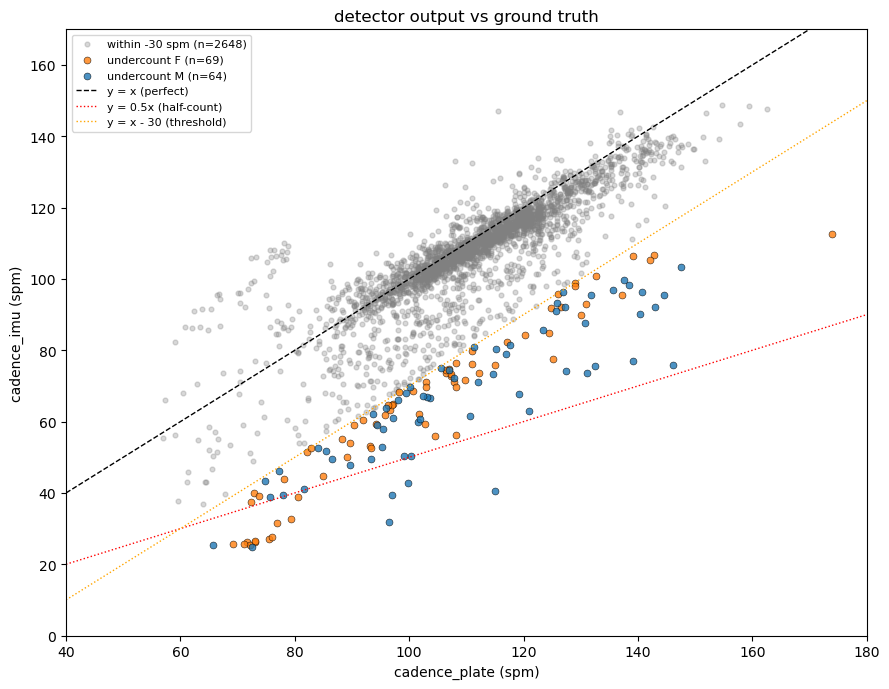

undercount trials: cadence_imu / cadence_plate
  mean: 0.611
  median: 0.645
  range: 0.331 to 0.765

by sex:
     count   mean    std    min    25%    50%    75%    max
sex                                                        
F     69.0  0.614  0.120  0.351  0.561  0.656  0.694  0.765
M     64.0  0.607  0.103  0.331  0.555  0.631  0.687  0.759


In [25]:
elig_annot = elig.assign(is_undercount=elig['cadence_error'] < -30)

fig, ax = plt.subplots(figsize=(9, 7))

# background: the well-behaved trials
clean = elig_annot[~elig_annot['is_undercount']]
ax.scatter(clean['cadence_plate'], clean['cadence_imu'],
           c='gray', alpha=0.3, s=12, label=f'within -30 spm (n={len(clean)})')

# foreground: undercount trials, colored by sex
for sex in SEX_ORDER:
    sub = elig_annot[(elig_annot['is_undercount']) & (elig_annot['sex'] == sex)]
    ax.scatter(sub['cadence_plate'], sub['cadence_imu'],
               c=SEX_COLORS[sex], alpha=0.8, s=25,
               edgecolor='black', linewidth=0.4,
               label=f'undercount {sex} (n={len(sub)})')

# reference lines: perfect / half-count / -30 threshold
x_range = np.array([40, 180])
ax.plot(x_range, x_range, color='black', linestyle='--', linewidth=1,
        label='y = x (perfect)')
ax.plot(x_range, 0.5 * x_range, color='red', linestyle=':', linewidth=1,
        label='y = 0.5x (half-count)')
ax.plot(x_range, x_range - 30, color='orange', linestyle=':', linewidth=1,
        label='y = x - 30 (threshold)')

ax.set_xlabel('cadence_plate (spm)')
ax.set_ylabel('cadence_imu (spm)')
ax.set_title('detector output vs ground truth')
ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(40, 180)
ax.set_ylim(0, 170)
plt.tight_layout()
fig.savefig(f"{OUTPUT_PATH}detector_vs_truth.png", dpi=200, bbox_inches="tight")
plt.show()

# ratio test: if it's half-count, imu/plate clusters at 0.5
undercount = elig_annot[elig_annot['is_undercount']].copy()
undercount['imu_over_plate'] = undercount['cadence_imu'] / undercount['cadence_plate']
print(f'undercount trials: cadence_imu / cadence_plate')
print(f'  mean: {undercount["imu_over_plate"].mean():.3f}')
print(f'  median: {undercount["imu_over_plate"].median():.3f}')
print(f'  range: {undercount["imu_over_plate"].min():.3f} to {undercount["imu_over_plate"].max():.3f}')
print(f'\nby sex:')
print(undercount.groupby('sex')['imu_over_plate'].describe().round(3).to_string())

### Per-subject undercount rate

- uniform across subjects or concentrated on a few?

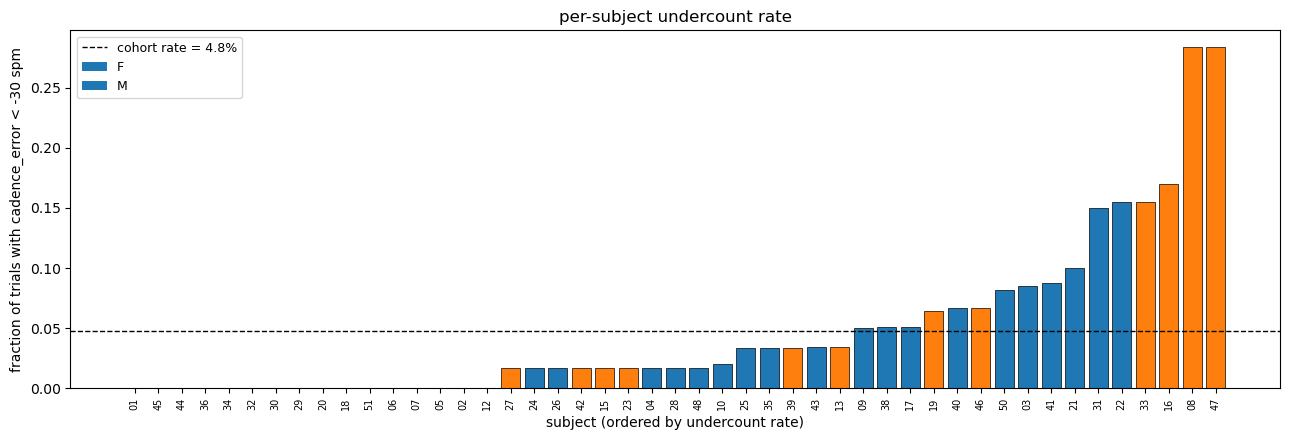

cohort rate: 4.8%
subjects with zero undercount: 16 / 47
subjects with > 10%: 6 / 47

top 10 by undercount rate:
subject_id sex  n_undercount  n_eligible  rate
        50   M             5          61  8.2%
        03   M             5          59  8.5%
        41   M             5          57  8.8%
        21   M             6          60 10.0%
        31   M             9          60 15.0%
        22   M             9          58 15.5%
        33   F             9          58 15.5%
        16   F            10          59 16.9%
        08   F            17          60 28.3%
        47   F            17          60 28.3%

by sex:
     count   mean    std  min  25%    50%    75%    max
sex                                                    
F     17.0  0.068  0.096  0.0  0.0  0.017  0.067  0.283
M     30.0  0.036  0.044  0.0  0.0  0.017  0.051  0.155


In [26]:
subj_undercount = (
    elig.assign(is_undercount=elig['cadence_error'] < -30)
        .groupby('subject_id')
        .agg(n_undercount=('is_undercount', 'sum'),
             n_eligible=('is_undercount', 'size'),
             sex=('sex', 'first'))
        .reset_index()
)
subj_undercount['rate'] = subj_undercount['n_undercount'] / subj_undercount['n_eligible']
subj_undercount = subj_undercount.sort_values('rate').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 4.5))
bar_colors = [SEX_COLORS[s] for s in subj_undercount['sex']]
ax.bar(range(len(subj_undercount)), subj_undercount['rate'],
       color=bar_colors, edgecolor='black', linewidth=0.5)

cohort_rate = (elig['cadence_error'] < -30).mean()
ax.axhline(cohort_rate, color='black', linestyle='--', linewidth=1,
           label=f'cohort rate = {cohort_rate:.1%}')

ax.set_xticks(range(len(subj_undercount)))
ax.set_xticklabels(subj_undercount['subject_id'], rotation=90, fontsize=7)
ax.set_xlabel('subject (ordered by undercount rate)')
ax.set_ylabel('fraction of trials with cadence_error < -30 spm')
ax.set_title('per-subject undercount rate')

for sex in SEX_ORDER:
    ax.bar([], [], color=SEX_COLORS[sex], label=sex)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
fig.savefig(f"{OUTPUT_PATH}per_subject_undercount.png", dpi=200, bbox_inches="tight")
plt.show()

print(f'cohort rate: {cohort_rate:.1%}')
print(f'subjects with zero undercount: {(subj_undercount["n_undercount"] == 0).sum()} / 47')
print(f'subjects with > 10%: {(subj_undercount["rate"] > 0.10).sum()} / 47')
print(f'\ntop 10 by undercount rate:')
print(
    subj_undercount.tail(10)[['subject_id', 'sex', 'n_undercount', 'n_eligible', 'rate']]
        .assign(rate=lambda d: d['rate'].map(lambda x: f'{x:.1%}'))
        .to_string(index=False)
)
print(f'\nby sex:')
print(subj_undercount.groupby('sex')['rate'].describe().round(3).to_string())